# Florida barrier-construction event study — panel descriptive statistics

**Source.** `data/florida/panel/assembled/event_study_panel.parquet`, built by
`python -m src.cli florida data panel assemble`
(`src/regions/florida/sources/panel/assemble.py`). It joins:

- **assessments** (outcome) — school x grade x subject x year test scores (now 2003-2026,
  four test regimes), standardised to `z_mss`,
- **schools** (spine) — Cluster-A covariates and static identity/filter fields,
- **schools assemble's rollup** — three parallel barrier-treatment-timing definitions
  (`point` / `same_route` / `same_side`, increasing matching rigour).

**This notebook** describes the assembled panel *as data* — shape, coverage, the outcome
distribution, covariate completeness, treatment-timing structure — the numbers an analysis
spec conditions on. It does not re-derive or justify any preprocessing choice; for the
intuition and diagnostics behind *why* each source looks the way it does, see the
`src/experiments/florida/` notebooks:

- [`assessments.ipynb`](../../../src/experiments/florida/assessments.ipynb) — score parsing,
  suppression, the four test-regime scale breaks (FCAT → FCAT 2.0 → FSA → FAST/B.E.S.T.),
  the within-cell z-score,
- [`barriers.ipynb`](../../../src/experiments/florida/barriers.ipynb) — inventory cleaning,
  school-barrier proximity features,
- [`road_network.ipynb`](../../../src/experiments/florida/road_network.ipynb) — roadway
  centreline source, milepost continuity,
- [`schools.ipynb`](../../../src/experiments/florida/schools.ipynb) — spine construction,
  Cluster-A covariates, the point / same-route / same-side matching-algorithm design.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)


def repo_root(start: Path | None = None) -> Path:
    """Walk up until we find the checkout (has both src/ and data/)."""
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
PANEL_PATH = ROOT / "data/florida/panel/assembled/event_study_panel.parquet"
FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)
assert PANEL_PATH.exists(), f"{PANEL_PATH} missing — run `python -m src.cli florida data panel assemble` first"

CRS_M = 3087
CRS_TILE = 3857
BASEMAP_LIGHT = cx.providers.Esri.WorldGrayCanvas


def add_basemap(ax, crs=CRS_M, source=BASEMAP_LIGHT, **kw):
    cx.add_basemap(ax, crs=crs, source=source, attribution_size=6, **kw)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("wrote", path.relative_to(ROOT))


ROOT


PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. Load & grain

In [2]:
panel = gpd.read_parquet(PANEL_PATH)
print("shape:", panel.shape)
print("CRS  :", panel.crs.to_epsg())

grain_cols = ["msid", "grade", "subject", "year"]
dupes = panel.duplicated(grain_cols).sum()
print(f"duplicate {tuple(grain_cols)} keys:", dupes)
print("distinct schools:", panel["msid"].nunique())
print("year range:", int(panel["year"].min()), "-", int(panel["year"].max()))

panel.head(3)


shape: (660681, 91)
CRS  : 3087
duplicate ('msid', 'grade', 'subject', 'year') keys: 0
distinct schools: 5039
year range: 2003 - 2026


,msid,grade,subject,year,subject_label,regime,retrofitted_2015,fcat_equivalent_2011,district_number,district_name,school_number,school_name,is_state_total,suppressed,n_students,mean_scale_score,pct_level3_plus,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5,z_mss,z_mss_w,source_file,in_operation,in_assessments,in_operation_src,ncessch,enrollment,enrollment_missing,frpl_n,frpl_n_missing,teachers_fte,teachers_fte_missing,title_i_status,ccd_charter,ccd_magnet,ccd_virtual,ccd_status,...,swd_n,crdc_total,pct_swd,pct_ell,read_prof_midpt,math_prof_midpt,msid_school_name,msid_district_name,school_type,is_regular,is_alternative,is_charter,is_magnet,is_virtual,grade_low,grade_high,serves_tested_grades,geometry,nearest_fdot_dist_m,nearest_fdot_gcid,n_walls_100m,n_walls_200m,n_walls_300m,n_walls_500m,n_walls_1000m,wall_len_500m,ever_near_wall_500m,ever_near_wall_1000m,first_treat_year_point,ever_treated_point,timing_unknown_point,first_treat_year_same_route,ever_treated_same_route,timing_unknown_same_route,first_treat_year_same_side,ever_treated_same_side,timing_unknown_same_side,event_time_point,event_time_same_route,event_time_same_side
0,010021,03,ELA,2003,English Language Arts,FCAT,False,False,01,ALACHUA,0021,DUVAL ELEM SCH,False,False,43,299,<NA>,14,19,44,23,0,0.11706,0.021193,FL2003_ELA_G03_school.xls,True,False,dates,120003000001,348.0,ok,345.0,ok,30.0,ok,NaN,0,-1,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,CHARLES W. DUVAL ELEMENTARY SCHOOL,ALACHUA,elementary,True,False,False,True,False,0,5,True,POINT (564559.189 629343.07),57015.7,726.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,NaN,False,False,NaN,False,False,NaN,False,False,NaN,NaN,NaN
1,010021,03,ELA,2004,English Language Arts,FCAT,False,False,01,ALACHUA,0021,DUVAL ELEM SCH,False,False,62,267,50,37,13,35,15,0,-1.293407,-1.462548,FL2004_ELA_G03_school.xls,True,False,dates,120003000001,395.0,ok,380.0,ok,26.0,ok,NaN,0,-1,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,CHARLES W. DUVAL ELEMENTARY SCHOOL,ALACHUA,elementary,True,False,False,True,False,0,5,True,POINT (564559.189 629343.07),57015.7,726.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,NaN,False,False,NaN,False,False,NaN,False,False,NaN,NaN,NaN
2,010021,03,ELA,2005,English Language Arts,FCAT,False,False,01,ALACHUA,0021,DUVAL ELEM SCH,False,False,74,281,59,30,11,47,11,1,-0.876252,-1.040492,FL2005_ELA_G03_school.xls,True,False,dates,120003000001,421.0,ok,396.0,ok,32.0,ok,NaN,0,-1,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,CHARLES W. DUVAL ELEMENTARY SCHOOL,ALACHUA,elementary,True,False,False,True,False,0,5,True,POINT (564559.189 629343.07),57015.7,726.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,NaN,False,False,NaN,False,False,NaN,False,False,NaN,NaN,NaN


660,681 rows on `(msid, grade, subject, year)` with no duplicate keys — the join in
`panel/assemble.py` is a clean `m:1` merge of covariates and treatment onto the
assessments grain, as designed. 5,039 distinct schools ever appear, spanning 23 spring
administrations 2003-2026 (2020 excluded — no spring testing).

## 2. Coverage: subjects, grades, regimes

wrote output/figures/florida/panel_coverage_subject_grade_regime.png


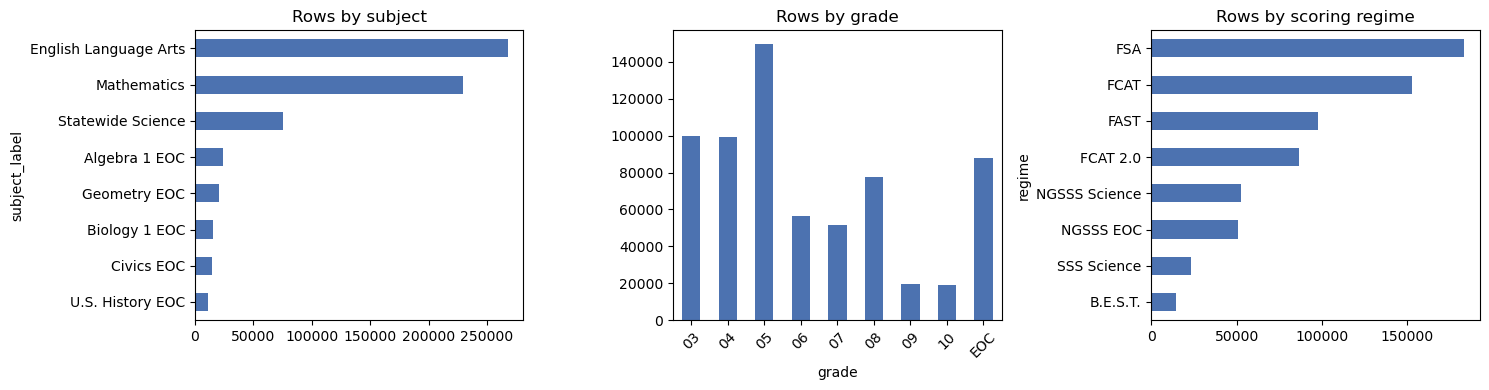

suppressed share: 0.1023


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

panel["subject_label"].value_counts().plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Rows by subject")
axes[0].invert_yaxis()

panel["grade"].value_counts().sort_index().plot.bar(ax=axes[1], color="#4c72b0")
axes[1].set_title("Rows by grade")
axes[1].tick_params(axis="x", rotation=45)

panel["regime"].value_counts().plot.barh(ax=axes[2], color="#4c72b0")
axes[2].set_title("Rows by scoring regime")
axes[2].invert_yaxis()

fig.tight_layout()
savefig(fig, "panel_coverage_subject_grade_regime.png")
plt.show()

print("suppressed share:", round(panel['suppressed'].mean(), 4))


ELA and Math dominate the row count (elementary/middle grades tested every year); the
five EOCs are thinner, grade-specific by construction (one high-school course each), and
only exist from 2011 on (plain FCAT, 2003-10, had no EOCs at all). About 10.2% of rows are
suppressed (`n < 10/20`, no score) — carried through from `assessments.ipynb`'s coverage
analysis; suppressed rows still contribute to the panel's covariate/treatment columns,
just not to `z_mss`.

## 3. Outcome: `z_mss`

count    593111.0
mean          0.0
std      0.999634
min     -6.711495
25%      -0.63357
50%      0.039588
75%      0.677623
max      4.847699
Name: z_mss, dtype: Float64


wrote output/figures/florida/panel_z_mss_distribution.png


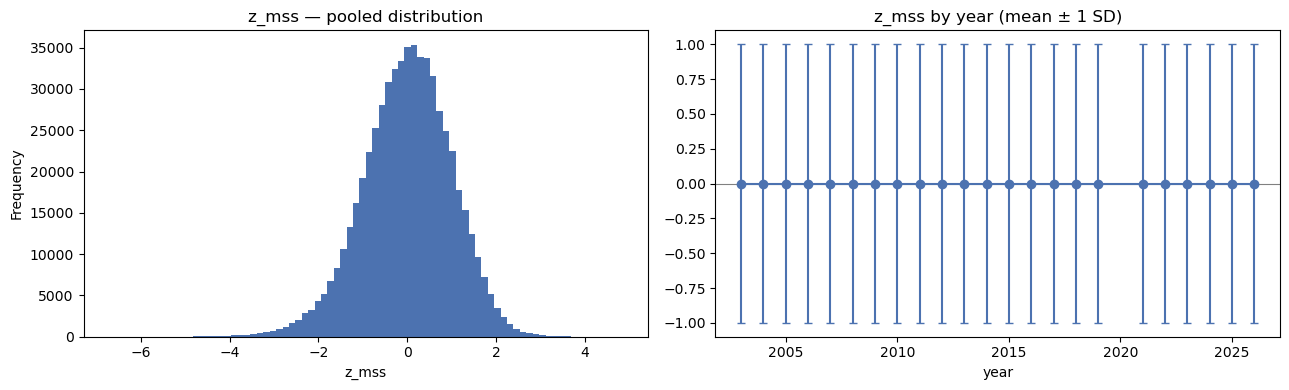

In [4]:
print(panel["z_mss"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

panel["z_mss"].dropna().plot.hist(bins=80, ax=axes[0], color="#4c72b0")
axes[0].set_title("z_mss — pooled distribution")
axes[0].set_xlabel("z_mss")

yearly = panel.groupby("year")["z_mss"].agg(["mean", "std", "count"])
axes[1].errorbar(yearly.index, yearly["mean"], yerr=yearly["std"], fmt="o-", color="#4c72b0", capsize=3)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("z_mss by year (mean ± 1 SD)")
axes[1].set_xlabel("year")

fig.tight_layout()
savefig(fig, "panel_z_mss_distribution.png")
plt.show()


By construction (`assessments.ipynb` §4) `z_mss` is mean 0, SD ≈ 1 within every
`year × subject × grade` cell, and that holds up pooled across the whole panel (mean
0.000, SD 1.000) with no drift by year — the regime-change standardisation the source
notebook validated (now across four regimes — FCAT → FCAT 2.0 → FSA → FAST/B.E.S.T. — not
one) survives the join intact. 593,111 of 660,681 rows carry a score (the remainder is
the suppressed 10.2% plus a handful of edge cases, e.g. 2003-05 Science's not-yet-defined
achievement levels don't affect `z_mss`, which is built on `mean_scale_score` directly).

## 4. Cluster-A covariates: completeness & distributions

In [5]:
covariate_cols = [
    "enrollment", "frpl_n", "teachers_fte", "pupil_teacher_ratio",
    "pct_white", "pct_black", "pct_hispanic", "pct_asian",
    "pct_swd", "pct_ell", "read_prof_midpt", "math_prof_midpt",
]
missing = panel[covariate_cols].isna().mean().sort_values(ascending=False)
missing.to_frame("share_missing")


,share_missing
pct_swd,0.712360
pct_ell,0.712360
math_prof_midpt,0.601690
read_prof_midpt,0.574038
pupil_teacher_ratio,0.108487
teachers_fte,0.090148
frpl_n,0.062641
pct_asian,0.058708
pct_black,0.058708
pct_hispanic,0.058708


`pct_swd` / `pct_ell` are missing on ~71% of rows, `read_prof_midpt` / `math_prof_midpt`
on ~57-60% — both pairs sit on collection cycles narrower than the panel's own 2003-2026
span: CRDC (`pct_swd`/`pct_ell`) only has data for the biennial years 2012/14/16/18/21/22
(every other year NA by construction, 2003-11 entirely so), EDFacts (`*_prof_midpt`) only
for 2009-2018 (~97% covered within that window, one sub-wave dip to 37% on
`math_prof_midpt` in 2013). Core CCD covariates (`enrollment`, race/ethnicity shares,
`frpl_n`, `teachers_fte`, `pupil_teacher_ratio`) sit at 6-11% missing — *lower* than in
the 2015-2026-only panel, because CCD's own historical coverage back to 2003 is solid and
dilutes out the non-reporting spikes concentrated in a few recent years.

wrote output/figures/florida/panel_covariate_distributions.png


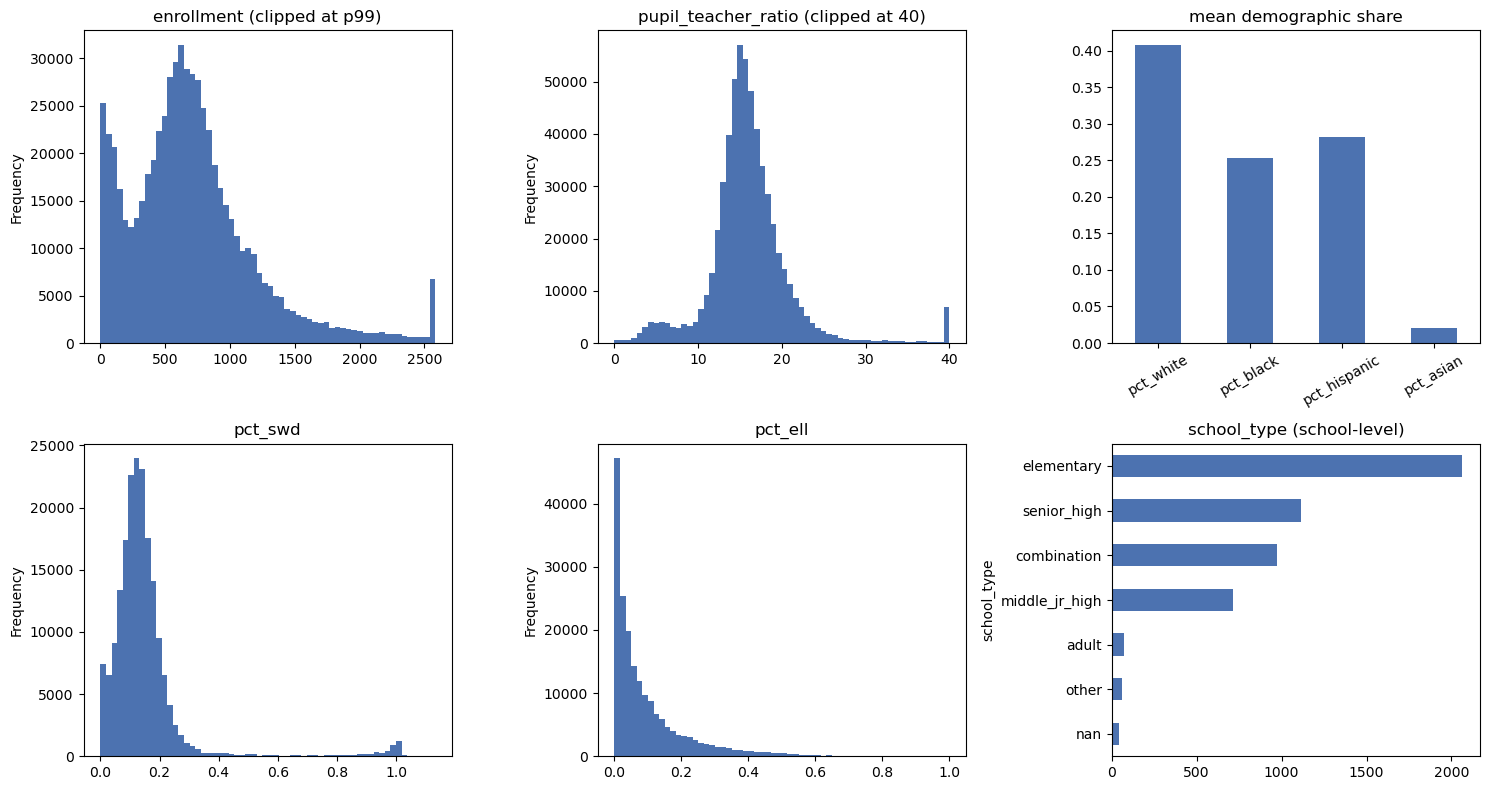

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

panel["enrollment"].dropna().clip(upper=panel["enrollment"].quantile(0.99)).plot.hist(
    bins=60, ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("enrollment (clipped at p99)")

panel["pupil_teacher_ratio"].dropna().clip(upper=40).plot.hist(bins=60, ax=axes[0, 1], color="#4c72b0")
axes[0, 1].set_title("pupil_teacher_ratio (clipped at 40)")

race_cols = ["pct_white", "pct_black", "pct_hispanic", "pct_asian"]
panel[race_cols].mean().plot.bar(ax=axes[0, 2], color="#4c72b0")
axes[0, 2].set_title("mean demographic share")
axes[0, 2].tick_params(axis="x", rotation=30)

panel["pct_swd"].dropna().plot.hist(bins=60, ax=axes[1, 0], color="#4c72b0")
axes[1, 0].set_title("pct_swd")

panel["pct_ell"].dropna().plot.hist(bins=60, ax=axes[1, 1], color="#4c72b0")
axes[1, 1].set_title("pct_ell")

sc = panel.drop_duplicates("msid")
sc["school_type"].value_counts(dropna=False).plot.barh(ax=axes[1, 2], color="#4c72b0")
axes[1, 2].set_title("school_type (school-level)")
axes[1, 2].invert_yaxis()

fig.tight_layout()
savefig(fig, "panel_covariate_distributions.png")
plt.show()


## 5. Treatment structure: point / same_route / same_side

In [7]:
definitions = ["point", "same_route", "same_side"]
rows = []
for d in definitions:
    et = panel[f"ever_treated_{d}"]
    rows.append({
        "definition": d,
        "ever_treated_schools": panel.loc[et, "msid"].nunique(),
        "ever_treated_rows": int(et.sum()),
        "timing_unknown_rows": int(panel[f"timing_unknown_{d}"].sum()),
    })
summary = pd.DataFrame(rows).set_index("definition")
summary


,ever_treated_schools,ever_treated_rows,timing_unknown_rows
definition,,,
point,513,68575,2814
same_route,293,39130,955
same_side,221,30375,839


The three definitions nest as designed: `same_route` ⊆ `point` and `same_side` ⊆
`same_route` (checked below) — each tier adds a stricter geometric requirement
(`schools.ipynb` §7) on top of the last, so tightening the match only removes schools, it
never adds a different set.

In [8]:
schools_by_def = {
    d: set(panel.loc[panel[f"ever_treated_{d}"], "msid"].unique()) for d in definitions
}
print("same_route subset of point:      ", schools_by_def["same_route"] <= schools_by_def["point"])
print("same_side subset of same_route:  ", schools_by_def["same_side"] <= schools_by_def["same_route"])
print("point-only (dropped by same_route):", len(schools_by_def["point"] - schools_by_def["same_route"]))
print("same_route-only (dropped by same_side):", len(schools_by_def["same_route"] - schools_by_def["same_side"]))


same_route subset of point:       True
same_side subset of same_route:   True
point-only (dropped by same_route): 220
same_route-only (dropped by same_side): 72


### Treatment timing vs. the panel window

`first_treat_year` is a wall's **construction** year — many barriers pre-date the
assessment panel (now 2003-2026, see `assessments.ipynb`) entirely. A school whose
nearest wall went up in, say, 1995 is treated in every panel year: it contributes no
pre-period and cannot identify an event-time effect on its own. Splitting ever-treated
schools by whether `first_treat_year` falls inside the panel window is the key design
fact for choosing an estimation sample.

In [9]:
PANEL_FIRST_YEAR = 2003   # update alongside assessments.ipynb if the raw stage extends further back

rows = []
for d in definitions:
    sc = panel.drop_duplicates("msid")
    et = sc[sc[f"ever_treated_{d}"]]
    known = et[~et[f"timing_unknown_{d}"]]
    pre_panel = (known[f"first_treat_year_{d}"] < PANEL_FIRST_YEAR).sum()
    in_window = known[f"first_treat_year_{d}"].between(PANEL_FIRST_YEAR, 2026).sum()
    rows.append({
        "definition": d,
        "ever_treated": len(et),
        "timing_known": len(known),
        f"first_treat_before_{PANEL_FIRST_YEAR} (always-treated in-sample)": pre_panel,
        f"first_treat_in_{PANEL_FIRST_YEAR}-2026 (usable event variation)": in_window,
    })
pd.DataFrame(rows).set_index("definition")

,ever_treated,timing_known,first_treat_before_2003 (always-treated in-sample),first_treat_in_2003-2026 (usable event variation)
definition,,,,
point,513,489,127,362
same_route,293,283,83,200
same_side,221,214,54,160


wrote output/figures/florida/panel_first_treat_year_distribution.png


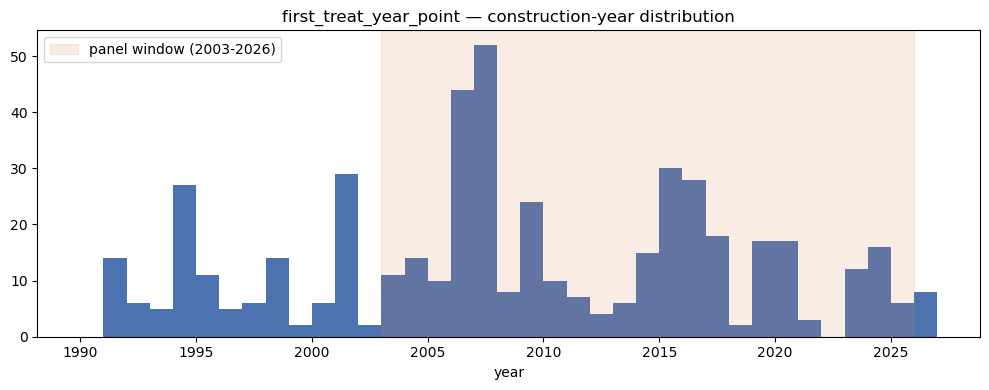

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sc = panel.drop_duplicates("msid")
years = sc.loc[sc["ever_treated_point"] & ~sc["timing_unknown_point"], "first_treat_year_point"]
ax.hist(years, bins=range(1990, 2028), color="#4c72b0")
ax.axvspan(PANEL_FIRST_YEAR, 2026, color="#dd8452", alpha=0.15, label=f"panel window ({PANEL_FIRST_YEAR}-2026)")
ax.set_title("first_treat_year_point — construction-year distribution")
ax.set_xlabel("year")
ax.legend()
fig.tight_layout()
savefig(fig, "panel_first_treat_year_distribution.png")
plt.show()

**This number just moved a lot, and in the direction that matters.** Under the loosest
definition (`point`), 362 of 489 timing-known ever-treated schools (74%) now have their
nearest wall built *inside* the panel window — up from 141/436 (32%) when the assessment
panel only reached back to 2015. The other two tiers move the same way: `same_route`
70.7% usable (was 30.2%), `same_side` 74.8% usable (was 32.6%). Extending the assessments
raw stage back to 2003 (today's work) didn't just add rows — it flipped the *majority* of
ever-treated schools from always-treated (no identifying variation) to schools with a
genuine pre-period, for every matching-rigour tier. An event-study spec still has a real,
definition-dependent ceiling on how many schools carry identifying variation — this is
not a data-quality issue, it reflects when Florida actually built its highway noise
barriers relative to when digitized FLDOE assessment data starts — but that ceiling is now
far less binding than it was.

## 6. Geography: treated vs. never-treated schools

wrote output/figures/florida/panel_treated_schools_statewide.png


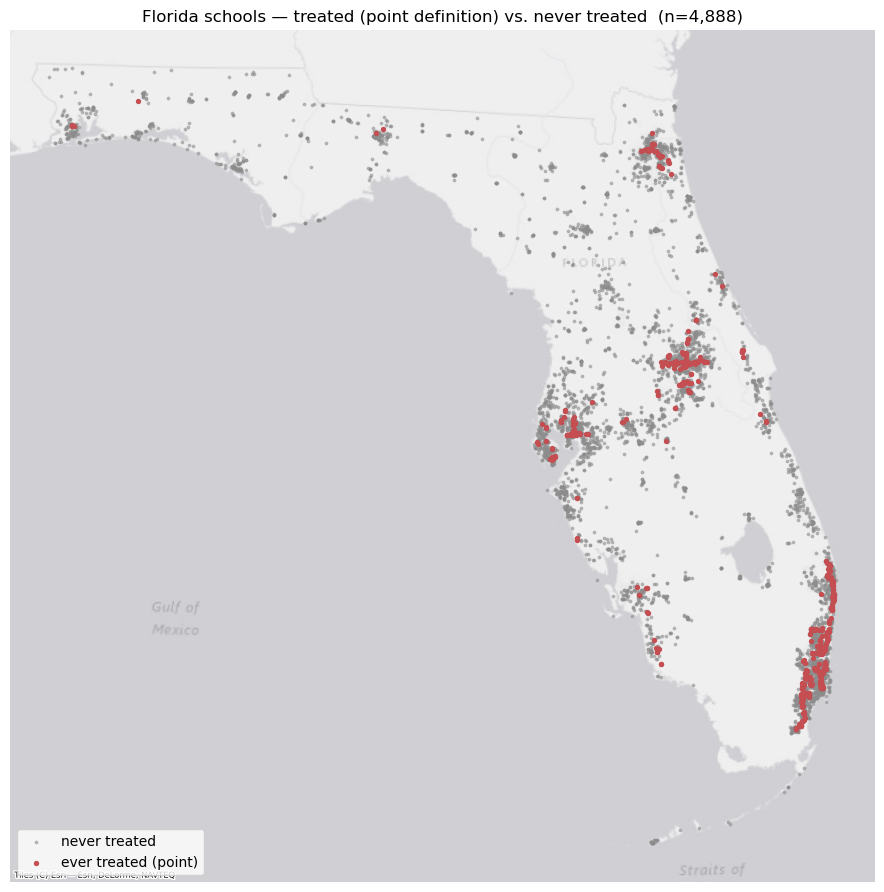

In [11]:
sc = panel.drop_duplicates("msid").dropna(subset=["geometry"])
sc = sc[~sc.geometry.is_empty]

fig, ax = plt.subplots(figsize=(9, 9))
sc[~sc["ever_treated_point"]].plot(ax=ax, markersize=3, color="#8c8c8c", alpha=0.5, label="never treated")
sc[sc["ever_treated_point"]].plot(ax=ax, markersize=8, color="#c44e52", label="ever treated (point)")
add_basemap(ax, crs=sc.crs)
ax.set_axis_off()
ax.legend(loc="lower left")
ax.set_title(f"Florida schools — treated (point definition) vs. never treated  (n={len(sc):,})")
fig.tight_layout()
savefig(fig, "panel_treated_schools_statewide.png")
plt.show()


Same footprint as `barriers.ipynb`'s statewide inventory map: treated schools cluster in
the three big urban corridors (South-East Florida, Metro Orlando, Tampa Bay) where the
noise-barrier inventory itself is concentrated — the treatment is not spread evenly across
the state, so any specification should expect the identifying variation to be
geographically clustered too.

## 7. Panel balance

wrote output/figures/florida/panel_schools_per_year_ela.png


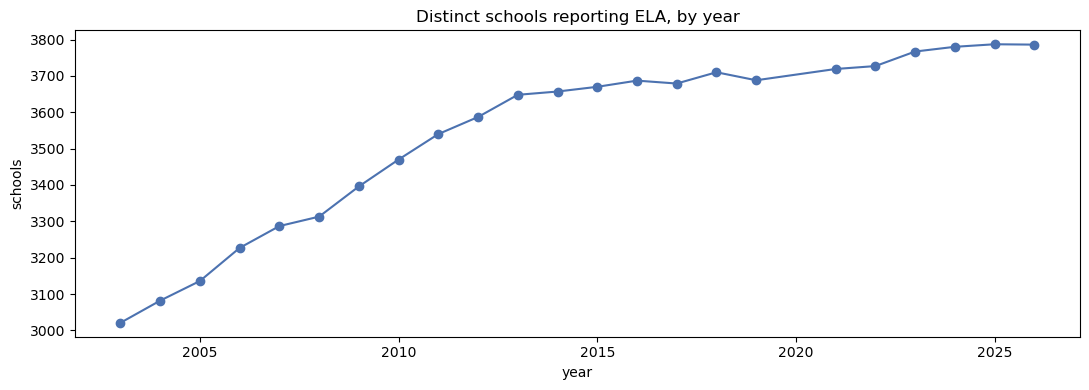

schools reporting ELA in every year 2003-2026: 2486
schools reporting ELA in at least one year:     4944


In [12]:
ela = panel[panel["subject_label"] == "English Language Arts"]
schools_per_year = ela.groupby("year")["msid"].nunique()

fig, ax = plt.subplots(figsize=(11, 4))
schools_per_year.plot(ax=ax, marker="o", color="#4c72b0")
ax.set_title("Distinct schools reporting ELA, by year")
ax.set_xlabel("year")
ax.set_ylabel("schools")
fig.tight_layout()
savefig(fig, "panel_schools_per_year_ela.png")
plt.show()

first_year = int(ela["year"].min())
always_present = set(ela.loc[ela["year"] == first_year, "msid"])
for y in sorted(ela["year"].unique()):
    always_present &= set(ela.loc[ela["year"] == y, "msid"])
ever_present = ela["msid"].unique()
print(f"schools reporting ELA in every year {first_year}-2026: {len(always_present)}")
print(f"schools reporting ELA in at least one year:     {len(ever_present)}")

Pooling across all ELA grades (03-10, any grade counts as "present") gives a larger
always-/ever-present count than `assessments.ipynb`'s own panel-shape check, which tracks
grade-05 ELA only (~1,500 always-present / ~3,000 ever-present there, 2003-2026) — the two
are consistent, not contradictory: a school missing grade 5 in a given year can still
report ELA for grades 3, 4, 6, 7, 8, 9 or 10, so the any-grade count is mechanically
higher. Either way the panel is unbalanced, inherited unchanged from the assessments
source through the join — and now the "always present" bar is much harder to clear, since
it has to hold over 23 years instead of 11.

## Summary

- **660,681 rows**, `(msid, grade, subject, year)` grain, no duplicate keys — 5,039
  distinct schools, 2003-2026 (2020 excluded).
- **Outcome** `z_mss`: mean 0 / SD ≈ 1 pooled, no drift across any of the four
  regime breaks (FCAT → FCAT 2.0 → FSA → FAST/B.E.S.T.) — the source notebook's
  standardisation survives the join. 593,111 rows carry a score; the rest is the
  assessments source's own 10.2% suppression.
- **Covariates**: CCD fields (enrollment, race/ethnicity, FRPL, staffing) 6-11% missing;
  CRDC fields (`pct_swd`, `pct_ell`) ~71% missing (biennial, 2012+ only) and EDFacts
  proficiency midpoints ~57-60% (2009-2018 only) — both reflect each source's own
  collection window being narrower than the panel's 2003-2026 span, not a join defect.
- **Treatment** is carried as three nested definitions — `same_side` ⊆ `same_route` ⊆
  `point` — 221 / 293 / 513 ever-treated schools respectively.
  **The headline change from extending the assessments raw stage to 2003**: 70-75% of
  ever-treated schools (up from ~31-33%) now have their nearest wall built *inside* the
  panel window, i.e. have a genuine pre-period — previously the *majority* were
  always-treated-in-sample with no identifying variation at all. This remains the single
  most consequential fact for choosing an event-study estimation sample, but the ceiling
  it imposes is now far less binding.
- **Geography**: treatment is concentrated in Florida's three major urban corridors, not
  spread statewide.
- **Panel shape**: unbalanced — 2,486 schools report ELA (any grade) every year across
  2003-2026, 4,944 ever; inherited unchanged from the assessments source through the left
  join.